In [13]:
import os
import random
random.seed(42)

import torch
import json
import pandas as pd 
import seaborn as sns
from tqdm import tqdm 
from PIL import Image
from matplotlib import pyplot as plt

from pixel import (
    AutoConfig,
    AutoModelForTokenClassification,
    get_transforms,
    get_attention_mask
)

from transformers import (
    BertTokenizer,
    BertModel,
    BertConfig
)

from pixel import PangoCairoBigramsRenderer

# Download WiC dataset

In [ ]:
# Download and unpack the WiC dataset
# Create the target directory if it doesn't exist
os.makedirs("../data/WiC_dataset", exist_ok=True)

# Download the dataset
!wget https://pilehvar.github.io/wic/package/WiC_dataset.zip -O ../data/WiC_dataset.zip

# Unzip the dataset
!unzip ../data/WiC_dataset.zip -d ../data/WiC_dataset

# Remove the zip file
os.remove("../data/WiC_dataset.zip")

# Prepare data

In [ ]:
def load_wic_data()->pd.DataFrame:
    """
    Load the WiC dataset train + dev from the specified directory.    
    """
    path_wic_train = "../data/WiC_dataset/train"
    path_wic_dev = "../data/WiC_dataset/dev"


    dev = pd.read_csv(os.path.join(path_wic_dev, "dev.data.txt"), 
                    sep='\t',
                    names=[
                        'target_word',
                        'noun_verb',
                        'PoS',
                        'example1',
                        'example2'
                    ])

    dev_label = pd.read_csv(os.path.join(path_wic_dev, "dev.gold.txt"), 
                    sep='\t',
                    names=[
                        'label',
                    ])

    dev = dev.join(dev_label)

    train = pd.read_csv(os.path.join(path_wic_train, "train.data.txt"), 
                    sep='\t',
                    names=[
                        'target_word',
                        'noun_verb',
                        'PoS',
                        'example1',
                        'example2'
                    ])
    train_label = pd.read_csv(os.path.join(path_wic_train, "train.gold.txt"), 
                    sep='\t',
                    names=[
                        'label',
                    ])

    train = train.join(train_label)

    df = pd.concat([train, dev])
    df.reset_index(inplace=True)
    return df

df = load_wic_data()
df

,index,target_word,noun_verb,PoS,example1,example2,label
0,0,carry,V,2-1,You must carry your camping gear .,Sound carries well over water .,F
1,1,go,V,2-6,Messages must go through diplomatic channels .,Do you think the sofa will go through the door ?,F
2,2,break,V,0-2,Break an alibi .,The wholesaler broke the container loads into ...,F
3,3,cup,N,8-4,He wore a jock strap with a metal cup .,Bees filled the waxen cups with honey .,T
4,4,academy,N,1-2,The Academy of Music .,The French Academy .,F
...,...,...,...,...,...,...,...
6061,633,base,N,9-0,He told the painter that he wanted a yellow ba...,Bases include oxides and hydroxides of metals ...,F
6062,634,power,N,5-6,He needed a lot of power to hit the ball out o...,The mysterious presence of an evil power .,F
6063,635,portmanteau,N,8-5,` brunch ' is a well - known portmanteau .,` motel ' is a portmanteau word made by combin...,T
6064,636,promise,V,1-1,I promise you my best effort .,I promised somebody my time .,T


#  pixel-base-bigrams

In [17]:
# Load the model configuration and model
pixel_model = "Team-PIXEL/pixel-base-bigrams"

pixel_config = AutoConfig.from_pretrained(
    pixel_model, 
    output_hidden_states=True)

model = AutoModelForTokenClassification.from_pretrained(pixel_model, config=pixel_config)

Some weights of the model checkpoint at Team-PIXEL/pixel-base-bigrams were not used when initializing PIXELForTokenClassification: ['decoder.decoder_layers.3.output.dense.weight', 'decoder.decoder_layers.0.intermediate.dense.bias', 'decoder.decoder_layers.2.attention.attention.key.bias', 'decoder.decoder_layers.4.attention.attention.key.weight', 'decoder.decoder_layers.1.attention.attention.value.weight', 'decoder.decoder_layers.1.layernorm_after.weight', 'decoder.mask_token', 'decoder.decoder_layers.5.layernorm_before.bias', 'decoder.decoder_layers.2.attention.output.dense.bias', 'decoder.decoder_layers.5.attention.attention.query.weight', 'decoder.decoder_layers.3.layernorm_before.weight', 'decoder.decoder_layers.5.intermediate.dense.bias', 'decoder.decoder_layers.3.layernorm_after.bias', 'decoder.decoder_layers.5.layernorm_after.bias', 'decoder.decoder_layers.2.attention.attention.query.weight', 'decoder.decoder_layers.1.attention.attention.query.weight', 'decoder.decoder_layers.1.o

In [9]:
# Initialize the renderer for bigrams
renderer = PangoCairoBigramsRenderer.from_pretrained(
    pixel_model,
    fallback_fonts_dir="../fonts/fonts",
    rgb=True,
    disable_fallback=False,   
)

In [23]:
# Define helper functions for preprocessing and rendering

def get_preprocess_fn(
    processor:PangoCairoBigramsRenderer,
):
    transforms = get_transforms(
        do_resize=True,
        size=(processor.pixels_per_patch, processor.pixels_per_patch * processor.max_seq_length),
    )
    def image_preprocess_fn(example):
        encodings = processor(text=example)
        out = {}

        out["pixel_values"] = transforms(Image.fromarray(encodings.pixel_values))
        out["attention_mask"] = get_attention_mask(encodings.num_text_patches, seq_length=processor.max_seq_length) 

        return out
    preprocess_fn = image_preprocess_fn
    return preprocess_fn


def preprocess_text(s: str) -> str:
    # no preprocessing 
    return s

def get_start_end(p:int, wpm:dict) -> tuple:
    if p == wpm.word_patch_map['word_list_truncation_index']:
        end = wpm.word_patch_map['first_patch_after_last_word'] + 1 # add one for cls 
    else:
        end = wpm.word_patch_map['word_order_on_canvas'][p+1]['start_patch_index']+1
    start = wpm.word_patch_map['word_order_on_canvas'][p]['start_patch_index']+1
    return (start, end)

def find_random_row(df:pd.DataFrame, x:str) -> int:
    """
    Returns random row labelled noun given a verb and vice versa
    """
    x = str(x).upper()
    if x == "N":
        sliced = df[df['noun_verb'] == 'V']
    elif x == "V":
        sliced = df[df['noun_verb'] == 'N']
    else:
        raise ValueError("Wrong letter. Must be either V(erb) or N(oun)")

    # Check if there are any rows
    if not sliced.empty:
        # Randomly select an index
        return df.loc[random.choice(sliced.index.tolist())].copy()
    else:
        # If there are no 'N' rows, return None
        return None


In [24]:
model = model.eval()
preprocess_fn = get_preprocess_fn(processor=renderer)

In [30]:
out_file = "output/PIXEL-base-bigrams-words_in_context-train-dev-cos_sim-mean-pooling.jsonl"
# Create output directory if it doesn't exist
os.makedirs(os.path.dirname(out_file), exist_ok=True)

cos_sim = torch.nn.CosineSimilarity(dim=0)
model.to('cuda') 

with open(out_file, "w") as fp:
    for idx, r in tqdm(df.iterrows(), total=len(df)):
        out = {}
        out['target_word'] = r['target_word']
        out['noun_verb'] = r['noun_verb']
        out['label'] = r['label']
        ran = find_random_row(df=df, x=r['noun_verb'])
        out['ran_target_word'] = ran['target_word']
        t1 = preprocess_text(r['example1'])
        x1 = preprocess_fn(t1)
        w1 = renderer(t1)
        t2 = preprocess_text(r['example2'])
        x2 = preprocess_fn(t2)
        w2 = renderer(t2)
        pos1, pos2 = r['PoS'].split('-')
        pos1, pos2 = int(pos1), int(pos2)
        s1, e1 = get_start_end(pos1, w1)
        s2, e2 = get_start_end(pos2, w2)
        
        ran_example = random.choice([1,2]) 
        if ran_example == 1:
            t3 = preprocess_text(ran['example1'])
            x3 = preprocess_fn(t3)
            w3 = renderer(t3)
            pos3, _ = ran['PoS'].split('-')
            pos3 = int(pos3)
            s3, e3 = get_start_end(pos3, w3)
            
        else:
            t3 = preprocess_text(ran['example2'])
            x3 = preprocess_fn(t3)
            w3 = renderer(t3)
            _, pos3 = ran['PoS'].split('-')
            pos3 = int(pos3)
            s3, e3 = get_start_end(pos3, w3)
        with torch.no_grad():
            hidden1 = model(
                x1['pixel_values'][None].to('cuda'), 
                x1['attention_mask'][None].to('cuda'),
            )['hidden_states']
            hidden2 = model(
                x2['pixel_values'][None].to('cuda'), 
                x2['attention_mask'][None].to('cuda'),
            )['hidden_states']
            hidden3 = model(
                x3['pixel_values'][None].to('cuda'), 
                x3['attention_mask'][None].to('cuda'),
            )['hidden_states']
        for l in range(len(hidden1)):
            h1 = hidden1[l].squeeze()[s1: e1] # e1 is first patch after word so no need to + 1 
            h2 = hidden2[l].squeeze()[s2: e2] 
            h3 = hidden3[l].squeeze()[s3: e3] 
            # *** mean pooling 
            hs1 = torch.sum(h1, dim=0) / h1.shape[0] 
            hs2 = torch.sum(h2, dim=0) / h2.shape[0]
            hs3 = torch.sum(h3, dim=0) / h3.shape[0]
            if not hs1.shape == hs2.shape:
                print(idx, r)
            out[f'cos_sim_hidden{l}'] = cos_sim(hs1, hs2).cpu().numpy().tolist()
            out[f'random_cos_sim_hidden{l}'] = cos_sim(random.choice([hs1, hs2]), hs3).cpu().numpy().tolist()
        
        json.dump(out, fp)
        fp.write('\n')

100%|██████████| 6066/6066 [11:58<00:00,  8.44it/s]


# BERT 

In [3]:
model_name = 'bert-base-cased'
tokenizer = BertTokenizer.from_pretrained(model_name)
config = BertConfig.from_pretrained(model_name, output_hidden_states=True)
model = BertModel.from_pretrained(model_name, config=config)

model = model.eval()

Some weights of the model checkpoint at bert-base-cased were not used when initializing BertModel: ['cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.weight', 'cls.seq_relationship.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [4]:
def sentence_to_token_offset_dict(sent:str, tokenizer:BertTokenizer) -> dict:
    out = {}
    offset = 1 # first one is CLS token 
    for enu, w in enumerate(sent.split(' ')):
        word_tokenized = tokenizer(w, add_special_tokens=False)['input_ids'] # don't include CLS and SEP tokens 
        # print(w, word_tokenized)
        word_len = len(word_tokenized)
        start, end = offset, offset + word_len - 1
        out[enu] = (start, end)
        offset += word_len 
    return out

def find_random_row(df:pd.DataFrame, x:str) -> int:
    """
    Returns random row labelled noun given a verb and vice versa
    """
    x = str(x).upper()
    if x == "N":
        sliced = df[df['noun_verb'] == 'V']
    elif x == "V":
        sliced = df[df['noun_verb'] == 'N']
    else:
        raise ValueError("Wrong letter. Must be either V(erb) or N(oun)")

    # Check if there are any rows
    if not sliced.empty:
        # Randomly select an index
        return df.loc[random.choice(sliced.index.tolist())].copy()
    else:
        # If there are no 'N' rows, return None
        return None


In [7]:
df = load_wic_data()
df['ex1_token_offset'] = df['example1'].apply(lambda x: sentence_to_token_offset_dict(sent=x, tokenizer=tokenizer))
df['ex2_token_offset'] = df['example2'].apply(lambda x: sentence_to_token_offset_dict(sent=x, tokenizer=tokenizer))

ran = find_random_row(df=df, x='N')
ran['example1']

'To admit a serious thought into the mind .'

In [8]:
out_file = "output/BERT-words_in_context-train-dev-cos_sim-mean-pooling2.jsonl"
os.makedirs(os.path.dirname(out_file), exist_ok=True)

cos_sim = torch.nn.CosineSimilarity(dim=0)
model.to('cuda')

with open(out_file, "w") as fp:
    for idx, r in tqdm(df.iterrows(), total=len(df)):
        out = {}
        out['target_word'] = r['target_word']
        out['noun_verb'] = r['noun_verb']
        out['label'] = r['label']
        ran = find_random_row(df=df, x=r['noun_verb'])
        out['ran_target_word'] = ran['target_word']
        t1 = tokenizer(r['example1'], padding="max_length", max_length=512, truncation=True, return_tensors='pt').to('cuda')
        t2 = tokenizer(r['example2'], padding="max_length", max_length=512, truncation=True, return_tensors='pt').to('cuda')
        pos1, pos2 = r['PoS'].split('-')
        pos1, pos2 = int(pos1), int(pos2)
        s1, e1 = r['ex1_token_offset'][pos1]
        s2, e2 = r['ex2_token_offset'][pos2]
        
        ran_example = random.choice([1,2]) 
        if ran_example == 1:
            t3 = tokenizer(ran['example1'], padding="max_length", max_length=512, truncation=True, return_tensors='pt').to('cuda')
            pos3, _ = ran['PoS'].split('-')
            pos3 = int(pos3)
            s3, e3 = ran['ex1_token_offset'][pos3]
            
        else:
            t3 = tokenizer(ran['example2'], padding="max_length", max_length=512, truncation=True, return_tensors='pt').to('cuda')
            _, pos3 = ran['PoS'].split('-')
            pos3 = int(pos3)
            s3, e3 = ran['ex2_token_offset'][pos3]
            
        with torch.no_grad():
            hidden1 = model(
                t1['input_ids'], 
                t1['attention_mask'],
            )['hidden_states']
            hidden2 = model(
                t2['input_ids'], 
                t2['attention_mask'],
            )['hidden_states']
            hidden3 = model(
                t3['input_ids'], 
                t3['attention_mask'],
            )['hidden_states']
        for l in range(len(hidden1)):
            h1 = hidden1[l].squeeze()[s1: e1 + 1] 
            h2 = hidden2[l].squeeze()[s2: e2 + 1]
            h3 = hidden3[l].squeeze()[s3: e3 + 1]
            # *** mean pooling 
            hs1 = torch.sum(h1, dim=0) / h1.shape[0] 
            hs2 = torch.sum(h2, dim=0) / h2.shape[0]
            hs3 = torch.sum(h3, dim=0) / h3.shape[0]
            if not hs1.shape == hs2.shape:
                print(idx, r)
            out[f'cos_sim_hidden{l}'] = cos_sim(hs1, hs2).cpu().numpy().tolist()
            out[f'random_cos_sim_hidden{l}'] = cos_sim(random.choice([hs1, hs2]), hs3).cpu().numpy().tolist()
        
            json.dump(out, fp)
            fp.write('\n')
        

100%|██████████| 6066/6066 [09:51<00:00, 10.25it/s]


# Plot

In [ ]:
# set custom color palette
# colors = ["#f4801f", "#00adc4", "#41157a", ]
colors=["#F4801F", "#32CD32", "#00ADC4", "#41157A", "#CC1E4A",]

custom_palette = sns.set_palette(sns.color_palette(colors))

# set font, size
# -- seaborn is a little obnoxious about font size, so this is scaling the plt value, and is ~14.5pt
sns.set_theme(style="ticks", palette=custom_palette, font_scale=1.2)
sns.set_style({'font.family':'serif', 'font.serif':'Times New Roman'})

## pixel-base-bigrams

In [13]:
res = "output/PIXEL-base-bigrams-words_in_context-train-dev-cos_sim-mean-pooling.jsonl"

with open(res, "r") as fp:
    res_json_list = list(fp)

dev_results = []
for j in res_json_list:
    res = json.loads(j)
    dev_results.append(res)
    
df = pd.DataFrame.from_dict(dev_results)
# create copy of df to separate out results on random 
df_random = df.copy()
# drop results on random from org df
cols_to_drop = df.filter(regex='^random_cos').columns
df = df.drop(cols_to_drop, axis=1)

# # Likewise, drop main from random results
cols_to_drop_ran = df.filter(regex='(?<!random_)cos_sim_hidden').columns
df_random = df_random.drop(cols_to_drop_ran, axis=1)

df 
# df_random

,target_word,noun_verb,label,ran_target_word,cos_sim_hidden0,cos_sim_hidden1,cos_sim_hidden2,cos_sim_hidden3,cos_sim_hidden4,cos_sim_hidden5,cos_sim_hidden6,cos_sim_hidden7,cos_sim_hidden8,cos_sim_hidden9,cos_sim_hidden10,cos_sim_hidden11,cos_sim_hidden12
0,carry,V,F,fair,0.972160,0.972508,0.971423,0.964271,0.952507,0.942600,0.908385,0.871195,0.815813,0.741218,0.662220,0.635612,0.771391
1,go,V,F,stopover,0.840066,0.868394,0.885658,0.871885,0.864744,0.860440,0.863878,0.860468,0.849861,0.834643,0.799548,0.756039,0.830850
2,break,V,F,pocket,0.834833,0.875531,0.898396,0.908672,0.888666,0.878949,0.841527,0.798234,0.719519,0.630741,0.566785,0.535865,0.681054
3,cup,N,T,run,0.831101,0.868335,0.903745,0.920101,0.910085,0.899132,0.864929,0.835871,0.796963,0.759781,0.717734,0.711576,0.792033
4,academy,N,F,pick,0.950672,0.957657,0.967077,0.969984,0.969956,0.971402,0.959633,0.935577,0.898666,0.869692,0.857147,0.862091,0.881828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6061,base,N,F,go,0.928140,0.904340,0.895623,0.880253,0.838953,0.821082,0.767094,0.722914,0.639428,0.544722,0.474803,0.436609,0.570983
6062,power,N,F,keep,0.852402,0.891197,0.926698,0.945706,0.938671,0.942513,0.928726,0.902044,0.859161,0.808831,0.772003,0.766311,0.814054
6063,portmanteau,N,T,take,0.895037,0.917354,0.939857,0.950874,0.950544,0.951900,0.951480,0.949243,0.928991,0.889418,0.817062,0.808187,0.848075
6064,promise,V,T,finish,0.998459,0.997772,0.997054,0.995306,0.987682,0.985010,0.969424,0.938979,0.913912,0.887110,0.857116,0.835649,0.862510


In [14]:
df_melt = pd.melt(
    df, 
    id_vars=['target_word', 'noun_verb', 'label', "ran_target_word"],
    var_name='layer', value_name='cos_sim'
    )
df_melt['layer'] = df_melt['layer'].apply(lambda x: int(''.join([z for z in x if z.isnumeric()])))
df_melt['label'] = df_melt['label'].apply(lambda x: "True" if x == "T" else "False")

df_melt_noun = df_melt[df_melt['noun_verb']=='N']
df_melt_verb = df_melt[df_melt['noun_verb']=='V']

df_random_melt = pd.melt(
    df_random, 
    id_vars=['target_word', 'noun_verb', 'label', "ran_target_word"],
    var_name='layer', value_name='cos_sim'
    )
df_random_melt['layer'] = df_random_melt['layer'].apply(lambda x: int(''.join([z for z in x if z.isnumeric()])))
df_random_melt['label'] = df_random_melt['label'].apply(lambda x: "True" if x == "T" else "False")

df_random_melt_noun = df_random_melt[df_random_melt['noun_verb']=='N']
df_random_melt_verb = df_random_melt[df_random_melt['noun_verb']=='V']

grouped_median = df_random_melt.groupby('layer')['cos_sim'].median().to_list()
grouped_median

[0.8470575511455536,
 0.8708569705486298,
 0.8815993666648865,
 0.8720862865447998,
 0.8334352970123291,
 0.8079531490802765,
 0.7505993843078613,
 0.6898868381977081,
 0.6041536927223206,
 0.5381273329257965,
 0.4622226655483246,
 0.4424316734075546,
 0.602870762348175]

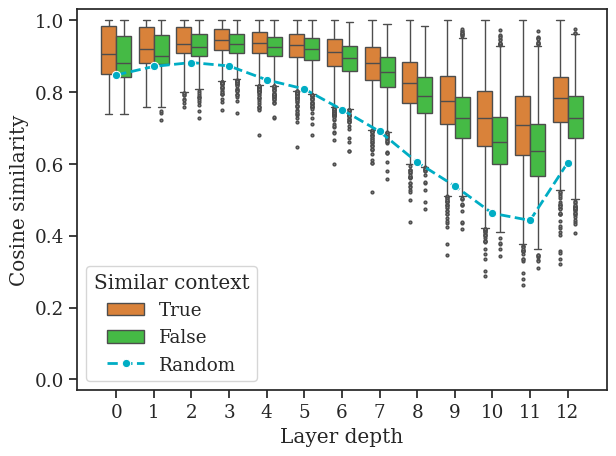

In [16]:
# sns boxplot example
fig = sns.boxplot(x="layer", y="cos_sim", hue="label", data=df_melt, 
                  dodge=0.3, 
                  flierprops = dict(markerfacecolor = '0.50', markersize = 2), 
                  showcaps=True,
                  #  notch=True, 
                  hue_order=['True', 'False'],
                  boxprops=dict(alpha=1.0),
                 )
fig = sns.lineplot(x=list(range(13)), y=grouped_median, color=colors[2], linewidth=2, marker="o", linestyle="dashed", label="Random")
plt.legend(title='Similar context',
           loc='lower left')
plt.xlabel('Layer depth')
plt.ylabel('Cosine similarity')
plt.ylim([-0.03,1.03])
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
# plt.title("Cosine similarity across hidden states for verbs in context")
plt.tight_layout()
plt.savefig('output/pixel-base-bigrams-wic-combined.pdf', dpi=500)
plt.show()

## BERT 

In [8]:
res = "output/BERT-words_in_context-train-dev-cos_sim-mean-pooling.jsonl"
with open(res, "r") as fp:
    res_json_list = list(fp)

dev_results = []
for j in res_json_list:
    res = json.loads(j)
    dev_results.append(res)

In [9]:
df = pd.DataFrame.from_dict(dev_results)
# create copy of df to separate out results on random 
df_random = df.copy()
# drop results on random from org df
cols_to_drop = df.filter(regex='^random_cos').columns
df = df.drop(cols_to_drop, axis=1)

# # Likewise, drop main from random results
cols_to_drop_ran = df.filter(regex='(?<!random_)cos_sim_hidden').columns
df_random = df_random.drop(cols_to_drop_ran, axis=1)

df 
# df_random

,target_word,noun_verb,label,ran_target_word,cos_sim_hidden0,cos_sim_hidden1,cos_sim_hidden2,cos_sim_hidden3,cos_sim_hidden4,cos_sim_hidden5,cos_sim_hidden6,cos_sim_hidden7,cos_sim_hidden8,cos_sim_hidden9,cos_sim_hidden10,cos_sim_hidden11,cos_sim_hidden12
0,carry,V,F,scene,0.731497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,carry,V,F,scene,0.731497,0.776170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,carry,V,F,scene,0.731497,0.776170,0.768321,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,carry,V,F,scene,0.731497,0.776170,0.768321,0.720237,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,carry,V,F,scene,0.731497,0.776170,0.768321,0.720237,0.743278,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78853,pierce,V,F,change,0.152251,0.194585,0.278397,0.375249,0.512147,0.62856,0.690342,0.685587,0.678485,NaN,NaN,NaN,NaN
78854,pierce,V,F,change,0.152251,0.194585,0.278397,0.375249,0.512147,0.62856,0.690342,0.685587,0.678485,0.727392,NaN,NaN,NaN
78855,pierce,V,F,change,0.152251,0.194585,0.278397,0.375249,0.512147,0.62856,0.690342,0.685587,0.678485,0.727392,0.757434,NaN,NaN
78856,pierce,V,F,change,0.152251,0.194585,0.278397,0.375249,0.512147,0.62856,0.690342,0.685587,0.678485,0.727392,0.757434,0.825634,NaN


In [10]:
df_melt = pd.melt(
    df, 
    id_vars=['target_word', 'noun_verb', 'label', "ran_target_word"],
    var_name='layer', value_name='cos_sim'
    )
df_melt['layer'] = df_melt['layer'].apply(lambda x: int(''.join([z for z in x if z.isnumeric()])))
df_melt['label'] = df_melt['label'].apply(lambda x: "True" if x == "T" else "False")

df_melt_noun = df_melt[df_melt['noun_verb']=='N']
df_melt_verb = df_melt[df_melt['noun_verb']=='V']

df_random_melt = pd.melt(
    df_random, 
    id_vars=['target_word', 'noun_verb', 'label', "ran_target_word"],
    var_name='layer', value_name='cos_sim'
    )
df_random_melt['layer'] = df_random_melt['layer'].apply(lambda x: int(''.join([z for z in x if z.isnumeric()])))
df_random_melt['label'] = df_random_melt['label'].apply(lambda x: "True" if x == "T" else "False")

df_random_melt_noun = df_random_melt[df_random_melt['noun_verb']=='N']
df_random_melt_verb = df_random_melt[df_random_melt['noun_verb']=='V']

grouped_median = df_random_melt.groupby('layer')['cos_sim'].median().to_list()
grouped_median

[0.08818884938955307,
 0.15844173729419708,
 0.22706745564937592,
 0.2614416182041168,
 0.3481280207633972,
 0.43081676959991455,
 0.4884704053401947,
 0.48190057277679443,
 0.5007007718086243,
 0.5950286686420441,
 0.6812857985496521,
 0.7750851511955261,
 0.598195493221283]

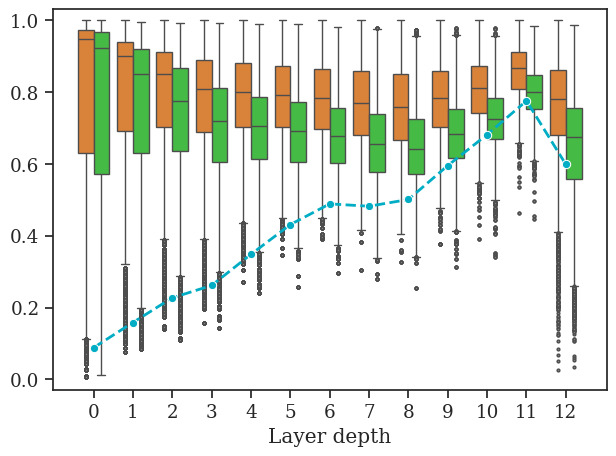

In [12]:
# sns boxplot example
fig = sns.boxplot(x="layer", y="cos_sim", hue="label", data=df_melt, 
                  dodge=0.3, 
                  flierprops = dict(markerfacecolor = '0.50', markersize = 2), 
                  showcaps=True,
                  #  notch=True, 
                  hue_order=['True', 'False'],
                  boxprops=dict(alpha=1.0),
                 )
fig = sns.lineplot(x=list(range(13)), y=grouped_median, color=colors[2], linewidth=2, marker="o", linestyle="dashed")
plt.legend('', frameon=False)
plt.xlabel('Layer depth')
plt.ylabel('')
plt.ylim([-0.03,1.03])
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
# plt.title("Cosine similarity across hidden states for verbs in context")
plt.tight_layout()
plt.savefig('output/bert-wic-combined.pdf', dpi=500)
plt.show()